Fraud detection - Kaggle project

Library

In [3]:
import pandas as pd


Dataset

In [48]:
df_transac = pd.read_csv('data/train_transaction.csv', nrows=50000)
df_id = pd.read_csv('data/train_identity.csv', nrows=50000)

print("Chargement partiel réussi !")
print(df_transac.head())
print(df_id.head())


Chargement partiel réussi !
   TransactionID  isFraud  TransactionDT  TransactionAmt ProductCD  card1  \
0        2987000        0          86400            68.5         W  13926   
1        2987001        0          86401            29.0         W   2755   
2        2987002        0          86469            59.0         W   4663   
3        2987003        0          86499            50.0         W  18132   
4        2987004        0          86506            50.0         H   4497   

   card2  card3       card4  card5  ... V330  V331  V332  V333  V334 V335  \
0    NaN  150.0    discover  142.0  ...  NaN   NaN   NaN   NaN   NaN  NaN   
1  404.0  150.0  mastercard  102.0  ...  NaN   NaN   NaN   NaN   NaN  NaN   
2  490.0  150.0        visa  166.0  ...  NaN   NaN   NaN   NaN   NaN  NaN   
3  567.0  150.0  mastercard  117.0  ...  NaN   NaN   NaN   NaN   NaN  NaN   
4  514.0  150.0  mastercard  102.0  ...  0.0   0.0   0.0   0.0   0.0  0.0   

  V336  V337  V338  V339  
0  NaN   NaN   NaN 

In [5]:
# Check dimensions of the loaded dataframes
print(f"Dimensions df_transac : {df_transac.shape}")
print(f"Dimensions df_id : {df_id.shape}")

Dimensions df_transac : (50000, 394)
Dimensions df_id : (50000, 41)


In [6]:
#Rate of isFraud in df_transac
fraud_rate = df_transac['isFraud'].mean() * 100
print(f"Pourcentage de transactions frauduleuses : {fraud_rate:.2f}%")

Pourcentage de transactions frauduleuses : 2.71%


We can firstly look if some columns have unique vqlues, then we will remove them.

In [ ]:
#df_transac
const_cols = [col for col in df_transac.columns if df_transac[col].nunique() == 1]
print(f"Colonnes constantes : {const_cols}")

print(df_transac[const_cols].isnull().sum())

print(df_transac.groupby(const_cols)['isFraud'].mean())

Colonnes constantes : ['M1', 'V107']
M1      32033
V107        0
dtype: int64
M1  V107
T   1.0     0.018423
Name: isFraud, dtype: float64
Colonnes constantes dans df_id : []
Series([], dtype: float64)


In [19]:
#Removing constant columns
df_transac = df_transac.drop(columns=const_cols)

Now, we will check the missing values

D7               95.288
dist2            93.290
D13              92.644
D12              91.806
D14              91.344
                  ...  
isFraud           0.000
V104              0.000
V105              0.000
V106              0.000
TransactionID     0.000
Length: 394, dtype: float64


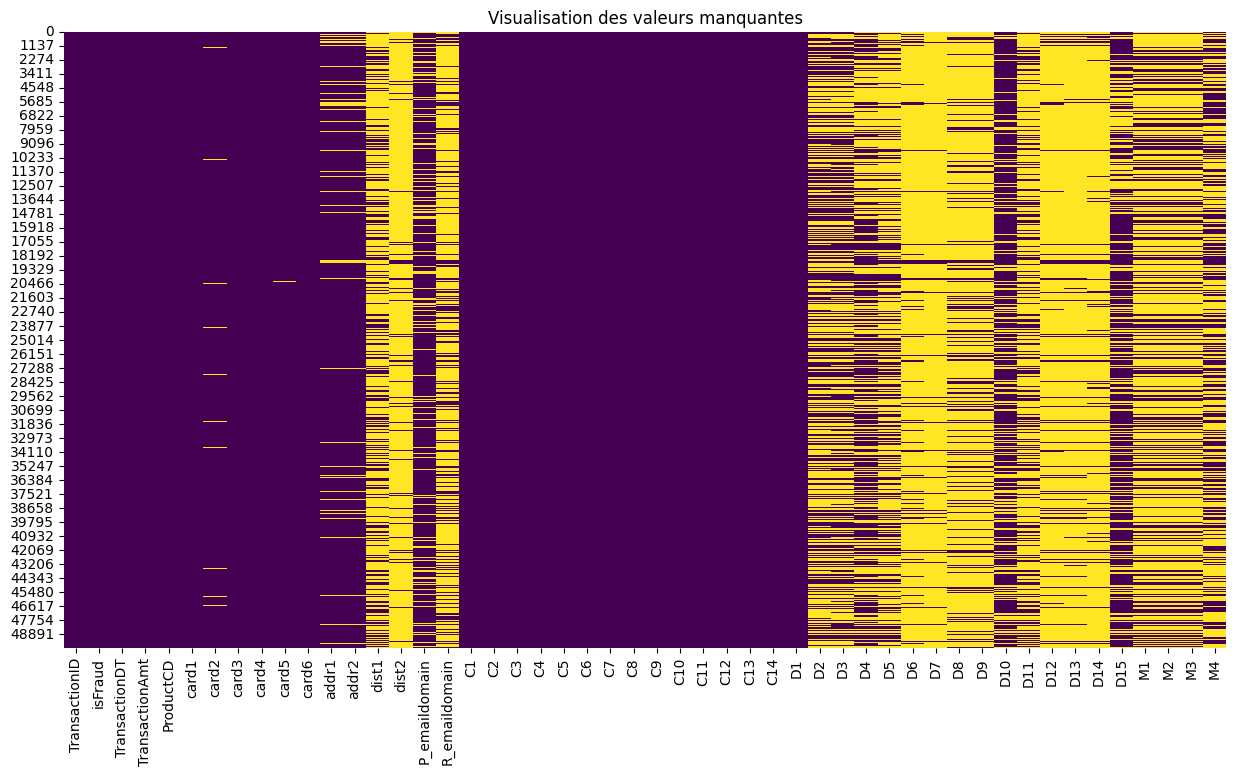

In [8]:
#Missing values check sorting

na_pourcentage = df_transac.isnull().mean() * 100
na_pourcentage.index = df_transac.columns
na_pourcentage = na_pourcentage.sort_values(ascending=False)
print(na_pourcentage)


import seaborn as sns
import matplotlib.pyplot as plt

# Visualise les 50 premières colonnes (pour ne pas saturer l'écran)
plt.figure(figsize=(15, 8))
sns.heatmap(df_transac.iloc[:, :50].isnull(), cbar=False, cmap='viridis')
plt.title("Visualisation des valeurs manquantes")
plt.show()

On a dataset with 50 000, we can remove variables with too much missing values.
I decided to remove all variables with more than 40% missing values.
Firstly, we will see if the missing values are information or not.

In [27]:
results = []

#loop to check the impact of missing values on the target variable 'isFraud'
for col in na_pourcentage.index:

    pourcentage = na_pourcentage[col]
    
    if pourcentage > 40:

        is_missing = df_transac[col].isnull().astype(int)
        
        fraud_rate_missing = df_transac[is_missing == 1]['isFraud'].mean() * 100
        fraud_rate_non_missing = df_transac[is_missing == 0]['isFraud'].mean() * 100

        diff = fraud_rate_missing - fraud_rate_non_missing

        ratio = (fraud_rate_missing / fraud_rate_non_missing) if fraud_rate_non_missing > 0 else float('inf')

        if diff == 0:
            print(f"The column {col} has no impact on the fraud rate.")
            df_transac = df_transac.drop(columns=[col])

        results.append({
            'column': col,
            'missing_percentage': pourcentage,
            'fraud_rate_missing': fraud_rate_missing,
            'fraud_rate_non_missing': fraud_rate_non_missing,
            'difference': diff,
            'ratio': ratio
        })

results_df = pd.DataFrame(results)
print(results_df.sort_values(by='difference', ascending=False))

    column  missing_percentage  fraud_rate_missing  fraud_rate_non_missing  \
8       M8              81.552            3.009123                1.409367   
9       M7              81.552            3.009123                1.409367   
10      M9              81.552            3.009123                1.409367   
188     M3              64.066            3.202947                1.842266   
187     M2              64.066            3.202947                1.842266   
..     ...                 ...                 ...                     ...   
5       D6              90.350            2.127283                8.207254   
4      D14              91.344            2.152303                8.641405   
2      D13              92.644            2.197660                9.216966   
3      D12              91.806            2.082653                9.787649   
0       D7              95.288            2.235329               12.393888   

     difference     ratio  
8      1.599756  2.135089  
9      

Now, we will proceed to an analysis by group.

In [54]:
#Analysis of variables C_ on the dataset df_transac

df_C = df_transac.filter(regex='^C', axis=1).copy()
print(df_C.head)

#summary of variables C_ in df_transac
print(df_C.describe())

<bound method NDFrame.head of         C1   C2   C3   C4   C5   C6   C7   C8   C9  C10  C11  C12   C13  C14
0      1.0  1.0  0.0  0.0  0.0  1.0  0.0  0.0  1.0  0.0  2.0  0.0   1.0  1.0
1      1.0  1.0  0.0  0.0  0.0  1.0  0.0  0.0  0.0  0.0  1.0  0.0   1.0  1.0
2      1.0  1.0  0.0  0.0  0.0  1.0  0.0  0.0  1.0  0.0  1.0  0.0   1.0  1.0
3      2.0  5.0  0.0  0.0  0.0  4.0  0.0  0.0  1.0  0.0  1.0  0.0  25.0  1.0
4      1.0  1.0  0.0  0.0  0.0  1.0  0.0  1.0  0.0  1.0  1.0  0.0   1.0  1.0
...    ...  ...  ...  ...  ...  ...  ...  ...  ...  ...  ...  ...   ...  ...
49995  4.0  3.0  0.0  0.0  3.0  4.0  0.0  0.0  3.0  0.0  4.0  0.0  76.0  2.0
49996  1.0  1.0  0.0  1.0  0.0  1.0  0.0  1.0  0.0  1.0  1.0  0.0   1.0  1.0
49997  1.0  1.0  0.0  0.0  1.0  1.0  0.0  0.0  0.0  0.0  1.0  0.0   1.0  1.0
49998  1.0  8.0  0.0  1.0  0.0  1.0  1.0  1.0  0.0  3.0  1.0  1.0   3.0  1.0
49999  1.0  1.0  0.0  1.0  0.0  1.0  0.0  1.0  0.0  1.0  1.0  0.0   1.0  1.0

[50000 rows x 14 columns]>
                 C

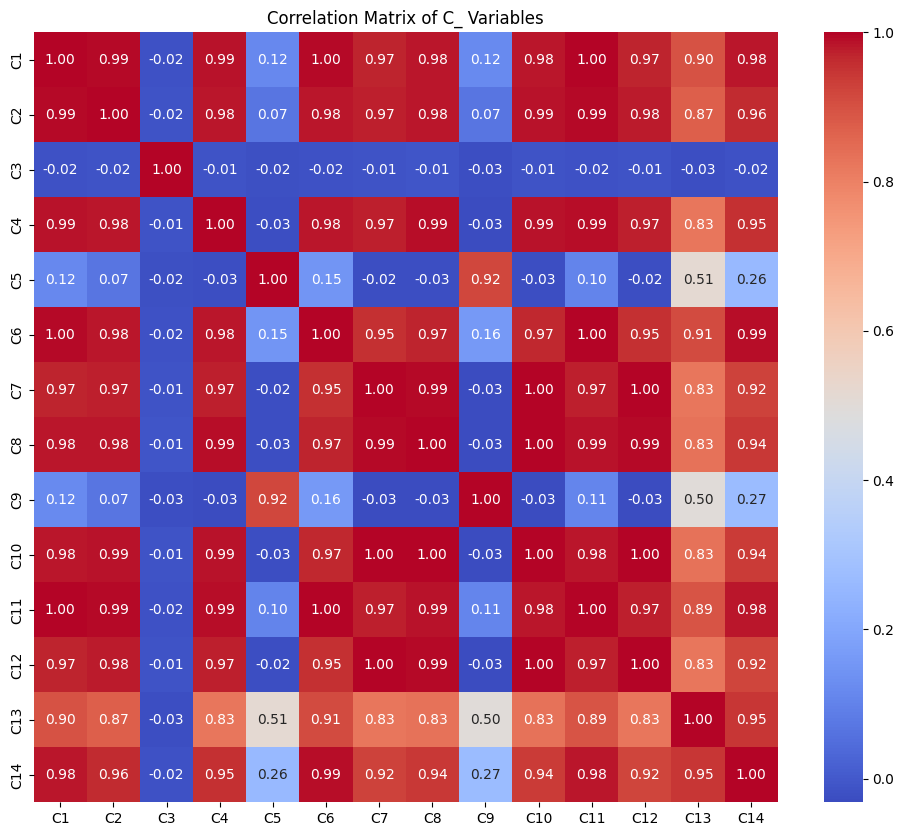

In [ ]:
#analysis on correlation between C_ variables

#Correlation matrix of C_ variables
corr_matrix = df_C.corr()
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm')
plt.title("Correlation Matrix of C_ Variables")
plt.show()

let's see 

/var/folders/tm/ltl1_5rx0lq1ps9g4gbyst380000gn/T/ipykernel_43207/1279541100.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/var/folders/tm/ltl1_5rx0lq1ps9g4gbyst380000gn/T/ipykernel_43207/1279541100.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/var/folders/tm/ltl1_5rx0lq1ps9g4gbyst380000gn/T/ipykernel_43207/1279541100.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/var/folders/tm/ltl1_5rx0lq1ps9g4gbyst380000gn/T/ipykernel_43207/1279541100.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated a

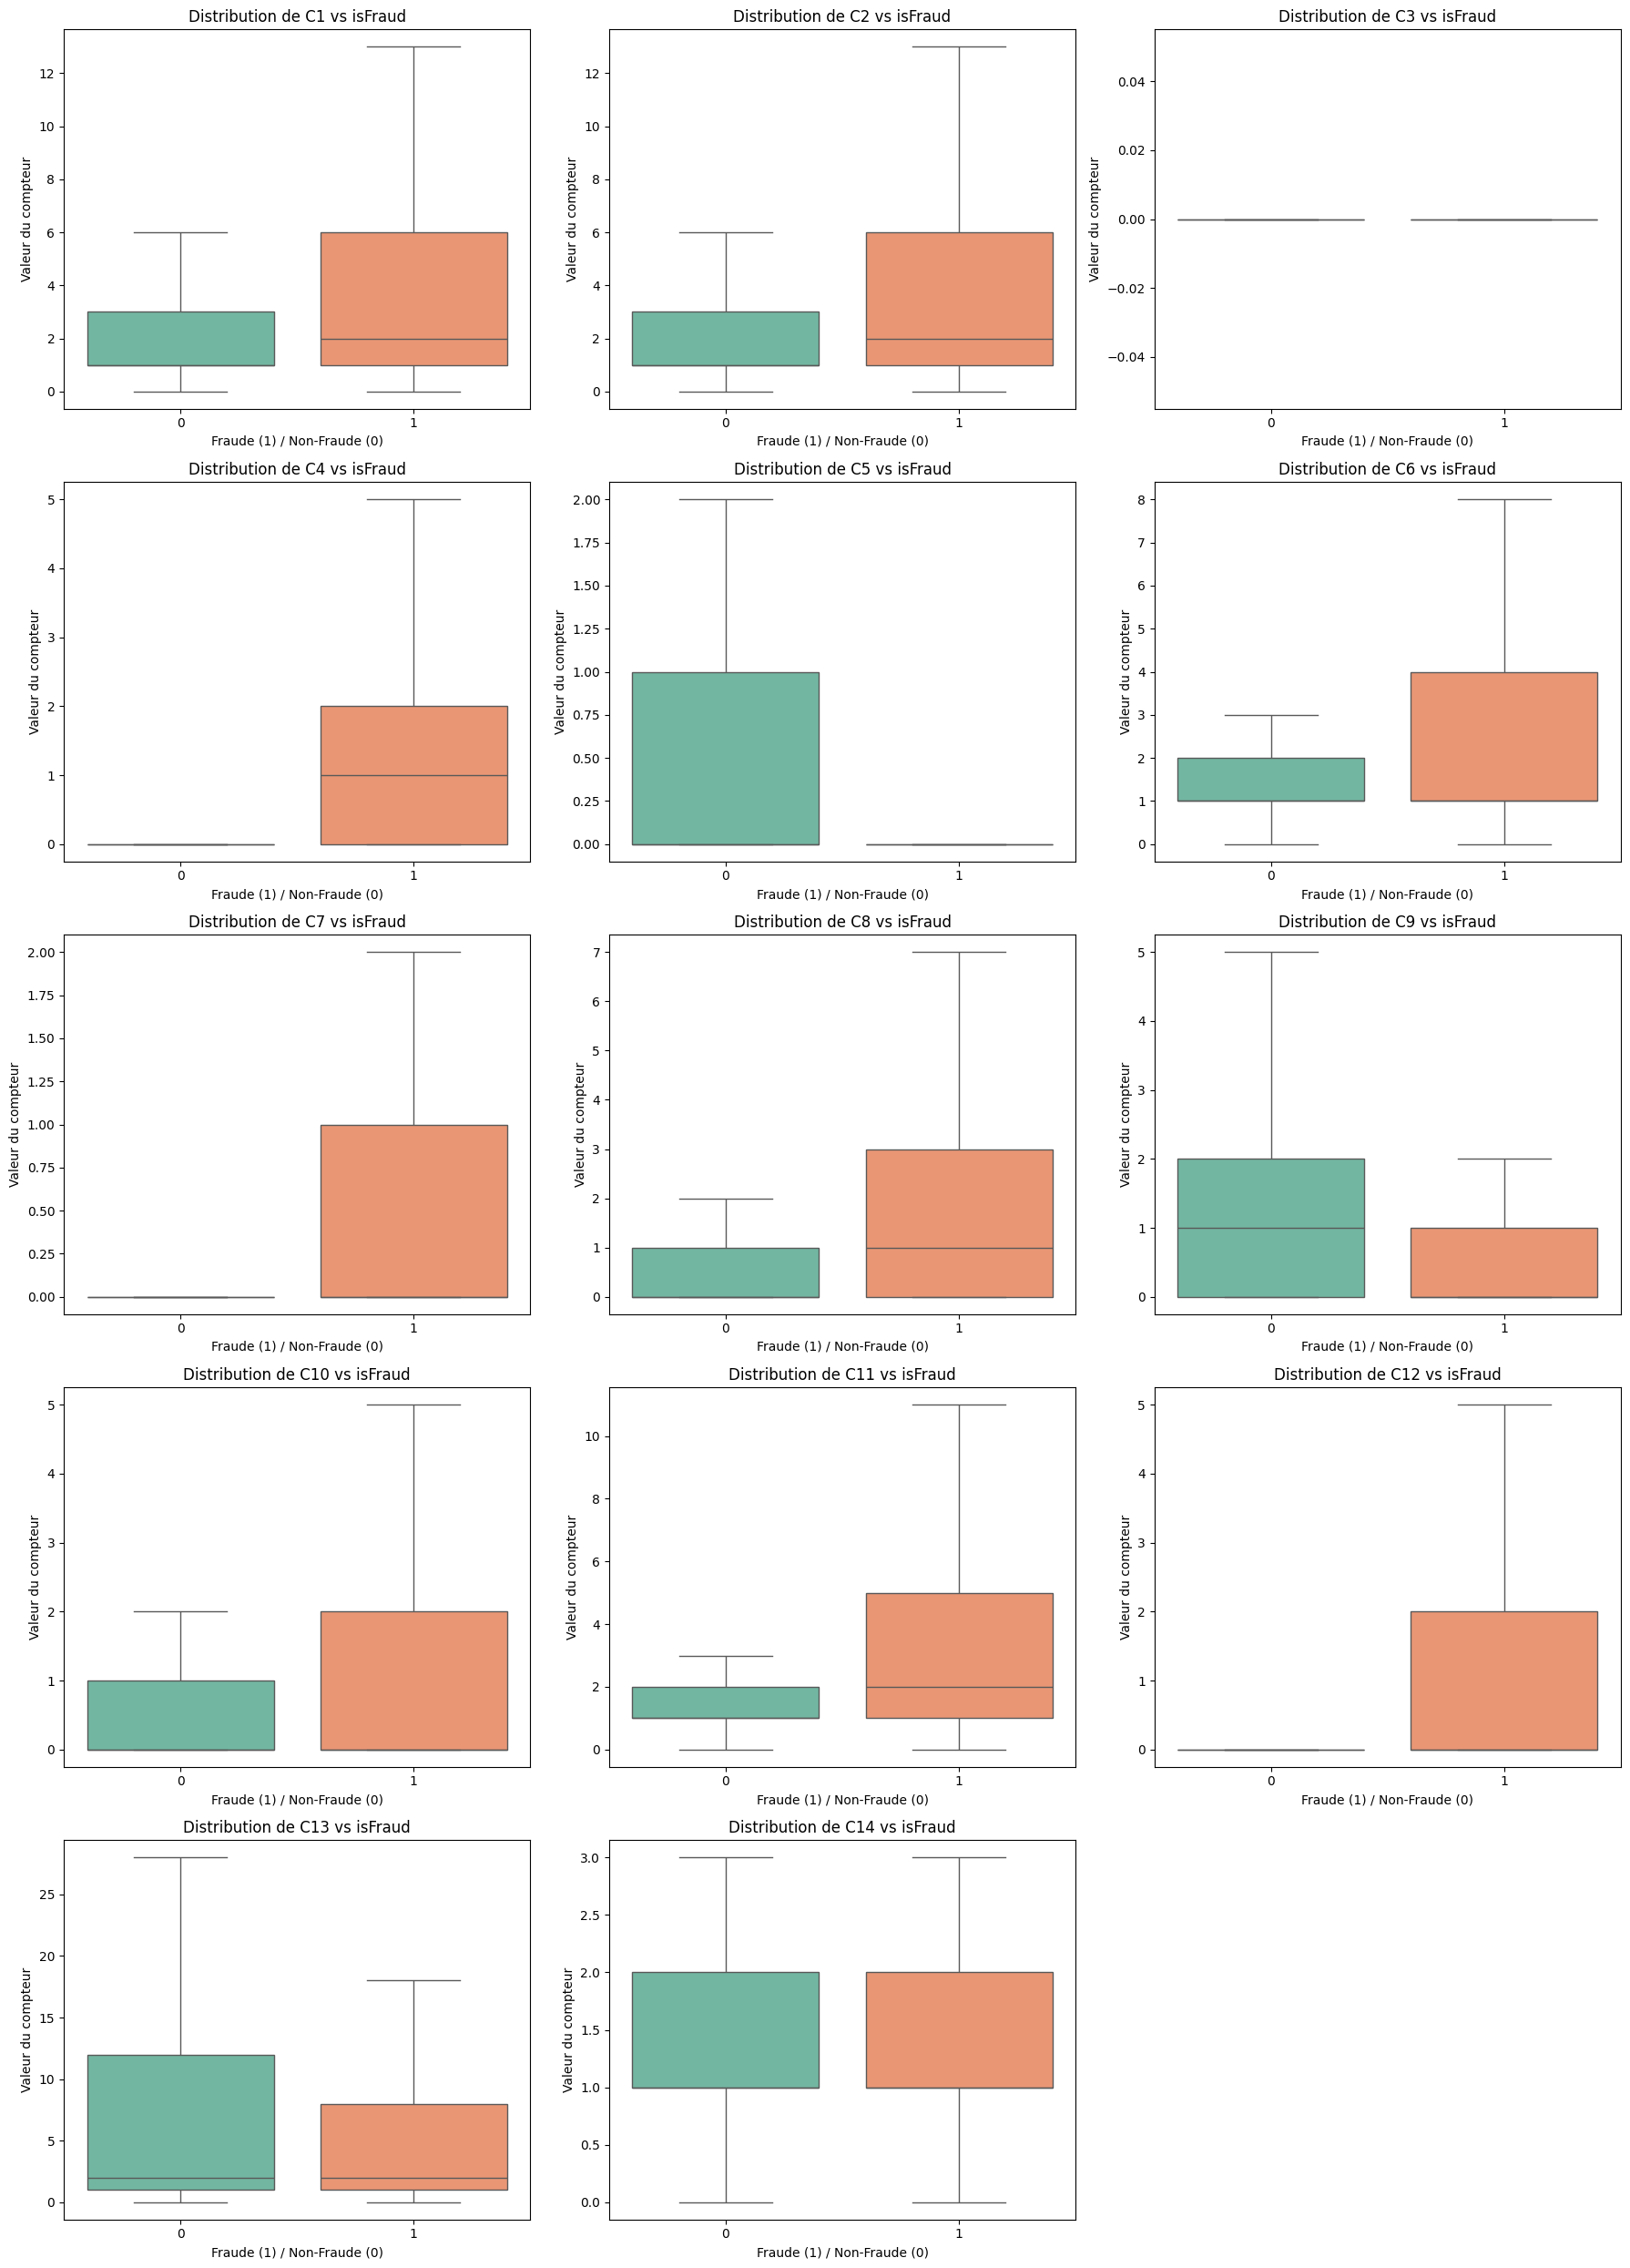

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

cols_C = [col for col in df_transac.columns if df_transac[col].nunique() > 1 and col.startswith('C') and col[1:].isdigit()]
df_plot = df_transac[cols_C + ['isFraud']].copy()


n_cols = 3
n_rows = int(np.ceil(len(cols_C) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 5 * n_rows))
axes = axes.flatten()

# loop to create boxplots for each C_ variable against isFraud
for i, col in enumerate(cols_C):

    sns.boxplot(
        data=df_plot, 
        x='isFraud', 
        y=col, 
        ax=axes[i], 
        palette='Set2',
        showfliers=False
    )
    axes[i].set_title(f'Distribution de {col} vs isFraud')
    axes[i].set_xlabel('Fraude (1) / Non-Fraude (0)')
    axes[i].set_ylabel('Valeur du compteur')


for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [ ]:
na_pourcentage = df_id.isnull().mean().sort_values(ascending=False) * 100
print(na_pourcentage)

id_24            96.446
id_25            96.192
id_21            96.176
id_07            96.170
id_08            96.170
id_26            96.170
id_23            96.168
id_27            96.168
id_22            96.168
id_18            68.952
id_03            56.354
id_04            56.354
id_09            49.076
id_10            49.076
id_33            31.542
id_30            26.090
id_32            26.086
id_34            25.918
id_14            25.010
id_13            17.894
DeviceInfo       11.388
id_16             7.626
id_06             5.564
id_05             5.564
id_20             3.538
id_19             3.534
id_17             3.510
id_31             2.774
DeviceType        2.674
id_02             2.658
id_28             2.436
id_29             2.436
id_15             2.436
id_11             2.436
id_35             2.436
id_36             2.436
id_37             2.436
id_38             2.436
id_01             0.000
id_12             0.000
TransactionID     0.000
dtype: float64
